# Phase 4: Anomaly and Outlier Detection

Home Credit Default Risk, KDD Phase 4.

No single detector sees every kind of outlier, so this phase runs five signals that look at the data from different angles and then asks how many of them agree:

1. IQR (univariate): flags a value outside the whiskers of its own column. Robust on skewed data, but blind to combinations.
2. Z-score (univariate): flags a value more than 3 standard deviations from its column mean. A sensitive complement to IQR, also blind to combinations.
3. Mahalanobis distance (multivariate, statistical): flags a row whose combination of values is far from the bulk once correlations are accounted for, even when every column alone looks fine. Uses a robust covariance (MCD) so the outliers cannot hide the ellipsoid they distort.
4. Isolation Forest (multivariate, structural): tree-based, no distribution assumption, catches non-linear pockets and interactions that a covariance ellipsoid cannot describe.
5. DBSCAN noise from Phase 2 (multivariate, density): points that sit in no dense region of the UMAP embedding, an independent cross-check from a different phase.

The more of these agree, the more confident we are. Each high-confidence anomaly then gets two labels, by theory scope and by business type, plus a recommendation.

Input: `datasets/final/features_clustering.csv` (Phase 1) and `datasets/final/cluster_labels.csv` (Phase 2, including the DBSCAN outlier flag).

Outputs land in `results/phase4_anomaly/`: the per-method outlier tables, the combined cross-method table, the summary, the per-record investigation CSV, and the plots. The written report lives in the project-root `REPORT.md`.

## 1. Setup and load

In [1]:
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT_DIR = PROJECT_ROOT / 'results/phase4_anomaly'
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = PROJECT_ROOT / 'datasets/final/features_clustering.csv'
LABELS_PATH = PROJECT_ROOT / 'datasets/final/cluster_labels.csv'

RANDOM_SEED = 42
SAMPLE_SIZE = None  # None = evaluasi SEMUA aplikasi (full dataset)
IQR_MULTIPLIER = 1.5
ZSCORE_THRESHOLD = 3.0
CONTAMINATIONS = [0.01, 0.05, 0.10]
DEFAULT_CONTAM = 0.05
MULTI_COL_RULE = 3  # outlier if flagged in >=3 columns

print(f'Loading features ...')
features = pd.read_csv(FEATURES_PATH)
labels = pd.read_csv(LABELS_PATH)
if 'ROW_ID' not in features.columns:
    features['ROW_ID'] = features.index
labels = labels.drop(columns=[c for c in ['SK_ID_CURR'] if c in labels.columns and c in features.columns])
df_merged = pd.merge(features, labels, on='ROW_ID', how='inner')
assert len(df_merged) == len(features), (
    f'cluster_labels.csv ({len(labels):,} rows) does not align with features ({len(features):,} rows) - re-run Phase 2!')
cluster_names_df = pd.read_csv(PROJECT_ROOT / 'datasets/final/cluster_names.csv')
print(f'  features: {features.shape}')
print(f'  labels  : {labels.shape}')
print(f'  merged  : {df_merged.shape}')

label_cols = ['ROW_ID', 'SK_ID_CURR', 'CLUSTER_KMEANS', 'CLUSTER_HIER', 'CLUSTER_DBSCAN', 'IS_OUTLIER']
numeric_cols = [c for c in df_merged.select_dtypes(include=['number']).columns if c not in label_cols]
df_features = df_merged[numeric_cols].copy()
null_pct = df_features.isnull().mean()
drop_cols = null_pct[null_pct > 0.5].index.tolist()
if drop_cols:
    print(f'  dropping {len(drop_cols)} cols >50% null: {drop_cols}')
    df_features = df_features.drop(columns=drop_cols)
df_features = df_features.fillna(df_features.median())

id_cols = [c for c in ['ROW_ID', 'SK_ID_CURR'] if c in df_merged.columns]
df_numeric = pd.concat([df_merged[id_cols].reset_index(drop=True), df_features.reset_index(drop=True)], axis=1)
df_with_labels = pd.concat([df_numeric, df_merged[['CLUSTER_KMEANS','IS_OUTLIER']].reset_index(drop=True)], axis=1)
df_numeric.to_csv(OUT_DIR / 'data_numeric.csv', index=False)
df_with_labels.to_csv(OUT_DIR / 'data_with_labels.csv', index=False)
print(f'\nNumeric features: {df_features.shape[1]}')
print(f'Saved data_numeric.csv & data_with_labels.csv')

Loading features ...


  features: (356255, 49)
  labels  : (356255, 5)
  merged  : (356255, 53)



Numeric features: 47
Saved data_numeric.csv & data_with_labels.csv


## 2. Univariate statistical outliers: IQR and Z-score

These two look at one column at a time.

IQR flags any value outside [Q1 minus 1.5 times IQR, Q3 plus 1.5 times IQR]. It is robust on skewed distributions because quartiles ignore the tail.

Z-score flags any value with absolute z above 3. It assumes a roughly normal distribution, which makes it more sensitive than IQR where that assumption roughly holds and noisier where it does not. Running both gives a robust view and a sensitive view of the same thing.

To avoid false alarms from a single extreme feature, a row counts as a statistical outlier only if it is flagged on at least 3 columns.

The honest limitation: both methods are blind to combinations. An applicant with a modest income and a modest loan can be perfectly ordinary on each column yet very strange together, for example when the loan is large only relative to that income. Catching those cases is the job of the multivariate methods in the next two sections.

In [2]:
def flag_iqr(df, mult=1.5):
    flags = pd.DataFrame(False, index=df.index, columns=df.columns)
    for col in df.columns:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        flags[col] = (df[col] < Q1 - mult*IQR) | (df[col] > Q3 + mult*IQR)
    return flags

def flag_zscore(df, thr=3.0):
    z = np.abs(stats.zscore(df, nan_policy='omit'))
    return pd.DataFrame(z > thr, index=df.index, columns=df.columns)

if SAMPLE_SIZE is None:
    sample = df_numeric.copy().reset_index(drop=True)   # full dataset
else:
    sample = df_numeric.sample(n=min(SAMPLE_SIZE, len(df_numeric)), random_state=RANDOM_SEED).reset_index(drop=True)
row_ids = sample['ROW_ID']
feat_sample = sample.drop(columns=[c for c in ['ROW_ID', 'SK_ID_CURR'] if c in sample.columns])

print(f'Sample: {len(sample):,} rows x {feat_sample.shape[1]} features')

print('Running IQR ...')
t0 = time.time()
iqr_flags = flag_iqr(feat_sample, mult=IQR_MULTIPLIER)
iqr_count = iqr_flags.sum(axis=1)
print(f'  Done in {time.time()-t0:.1f}s')

print('Running Z-score ...')
t0 = time.time()
z_flags = flag_zscore(feat_sample, thr=ZSCORE_THRESHOLD)
z_count = z_flags.sum(axis=1)
print(f'  Done in {time.time()-t0:.1f}s')

stats_df = pd.DataFrame({
    'ROW_ID': row_ids,
    'iqr_outlier_count': iqr_count,
    'zscore_outlier_count': z_count,
    'is_iqr_outlier': iqr_count >= MULTI_COL_RULE,
    'is_zscore_outlier': z_count >= MULTI_COL_RULE,
})
stats_df['is_statistical_outlier'] = stats_df['is_iqr_outlier'] | stats_df['is_zscore_outlier']
def get_method(r):
    if r['is_iqr_outlier'] and r['is_zscore_outlier']: return 'Both'
    if r['is_iqr_outlier']: return 'IQR'
    if r['is_zscore_outlier']: return 'Z-score'
    return 'None'
stats_df['statistical_method'] = stats_df.apply(get_method, axis=1)
stats_df.to_csv(OUT_DIR / 'statistical_outliers.csv', index=False)

print(f'\n--- Statistical Summary ---')
print(f'  IQR outliers      : {int(stats_df["is_iqr_outlier"].sum()):,}')
print(f'  Z-score outliers  : {int(stats_df["is_zscore_outlier"].sum()):,}')
print(f'  Statistical (any) : {int(stats_df["is_statistical_outlier"].sum()):,}')
print(f'  Both methods      : {int((stats_df["statistical_method"]=="Both").sum()):,}')

print('\nTop 5 features triggering IQR outliers:')
print(iqr_flags.sum().sort_values(ascending=False).head(5).to_string())

Sample: 356,255 rows x 47 features
Running IQR ...


  Done in 0.7s
Running Z-score ...


  Done in 1.4s



--- Statistical Summary ---
  IQR outliers      : 201,278
  Z-score outliers  : 8,822
  Statistical (any) : 201,278
  Both methods      : 8,822

Top 5 features triggering IQR outliers:
EXT_SOURCE_1                   162342
REGION_RATING_CLIENT_W_CITY     90995
INST_PAYMENT_RATIO_MEAN         75709
CC_AMT_BALANCE_MEAN             70233
CC_UTILIZATION_MEAN             70063


## 3. Isolation Forest: multivariate detection without distribution assumptions

Isolation Forest is an ensemble of random partition trees. A row that is easy to separate from the rest gets isolated in the early splits, so its average path length is short and its score is low.

Why keep it alongside Mahalanobis (next section)? The two make opposite trade-offs. Mahalanobis assumes the bulk of the data forms one ellipsoid; it is precise when that holds and misleading when the data has curved or multi-lobed structure. Isolation Forest assumes nothing about shape, so it catches non-linear pockets and odd interactions, at the cost of being less interpretable. Using both means a row flagged by each is strange under two very different definitions of strange.

We run it at three contamination levels (0.01, 0.05, 0.10) as a sensitivity check, and use 0.05 as the default.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_sample)
iso_df = pd.DataFrame({'ROW_ID': row_ids})

for c in CONTAMINATIONS:
    print(f'Running Isolation Forest (contamination={c}) ...')
    t0 = time.time()
    iso = IsolationForest(n_estimators=100, contamination=c, random_state=RANDOM_SEED, n_jobs=-1)
    preds = iso.fit_predict(X_scaled)
    scores = iso.score_samples(X_scaled)
    iso_df[f'is_isolation_outlier_{c}'] = (preds == -1)
    iso_df[f'isolation_score_{c}'] = scores
    print(f'  Done in {time.time()-t0:.1f}s | outliers={int((preds==-1).sum())}')

iso_df['is_isolation_outlier'] = iso_df[f'is_isolation_outlier_{DEFAULT_CONTAM}']
iso_df['isolation_score'] = iso_df[f'isolation_score_{DEFAULT_CONTAM}']
iso_df.to_csv(OUT_DIR / 'isolation_forest_outliers.csv', index=False)

print(f'\nDefault (contam={DEFAULT_CONTAM}): {int(iso_df["is_isolation_outlier"].sum()):,} outliers')
print(f'Score range: {iso_df["isolation_score"].min():.4f} to {iso_df["isolation_score"].max():.4f}')

Running Isolation Forest (contamination=0.01) ...


  Done in 15.5s | outliers=3563
Running Isolation Forest (contamination=0.05) ...


  Done in 12.3s | outliers=17813
Running Isolation Forest (contamination=0.1) ...


  Done in 12.7s | outliers=35626



Default (contam=0.05): 17,813 outliers
Score range: -0.6683 to -0.3639


## 4. Mahalanobis distance: the combination-aware detector

Euclidean distance treats every feature as independent and equally scaled. Mahalanobis distance instead measures how far a row sits from the centre of the data *along the correlation structure*: it stretches distances in directions where the data is tight and shrinks them where the data naturally spreads. That makes it the classic statistical answer to the question the univariate methods cannot ask: is this *combination* of values unusual?

Two practical choices need justifying.

First, the covariance is estimated robustly with MCD (Minimum Covariance Determinant) rather than the ordinary sample covariance. The ordinary estimate has a masking problem: the outliers we are hunting inflate the covariance themselves, which stretches the ellipsoid around them and makes them look normal. MCD fits the covariance on the tightest-fitting subset of rows, so the ellipsoid stays anchored to the ordinary bulk and the outliers stand out from it. The estimate is fitted on a 20 thousand row sample (the estimator is expensive), then every one of the 356 thousand rows is scored against it, which is a cheap matrix operation.

Second, the distance uses only the genuinely continuous features. A covariance ellipsoid describes elliptical data; binary flags and few-valued ordinals break that badly and can even make the fitted covariance singular. The flags are not lost: they are exactly what IQR, Z-score, and Isolation Forest already handle.

The cut-off deserves honesty. The textbook threshold says that under normality, squared Mahalanobis distances follow a chi-square distribution with as many degrees of freedom as features, so one flags rows beyond a high quantile of that distribution. We compute that threshold and show what happens: it flags roughly a third of the portfolio, which is not outlier detection, it is a demonstration that credit data grossly violates normality (heavy tails, zero-inflated behaviour columns). So we do what a practitioner does when the parametric assumption fails: calibrate empirically, flagging the top 2.5 percent of robust distances. That keeps the flag rate in the same order as the other multivariate detectors and leaves the final judgement to the agreement of several methods rather than any single cut-off.

In [4]:
from sklearn.covariance import MinCovDet
from scipy.stats import chi2

# Mahalanobis needs a covariance estimate, and covariance describes elliptical
# data. Binary flags and few-valued ordinals can make the MCD subset singular,
# so the distance uses only the genuinely continuous columns (already
# standardized by the scaler above).
cont_cols = [c for c in feat_sample.columns if feat_sample[c].nunique() > 10]
X_cont = feat_sample[cont_cols].values.astype(np.float64)
print(f'Mahalanobis feature set: {len(cont_cols)} continuous columns '
      f'({feat_sample.shape[1] - len(cont_cols)} binary/ordinal columns excluded)')

# Robust covariance (MCD): the classical estimate is stretched by the very
# outliers we are hunting (the masking effect), so it is fitted on the
# tightest subset instead. support_fraction=0.75 trades a little robustness
# for stability on semi-discrete columns.
MCD_SAMPLE = 20000
rng_m = np.random.default_rng(RANDOM_SEED)
midx = rng_m.choice(len(X_cont), size=min(MCD_SAMPLE, len(X_cont)), replace=False)
print(f'Fitting MinCovDet on a {len(midx):,}-row sample ...')
t0 = time.time()
mcd = MinCovDet(random_state=RANDOM_SEED, support_fraction=0.75).fit(X_cont[midx])
print(f'  Done in {time.time()-t0:.1f}s')

# Score every row against the robust ellipsoid (cheap quadratic form).
t0 = time.time()
mahal_d2 = mcd.mahalanobis(X_cont)
print(f'  Scored {len(mahal_d2):,} rows in {time.time()-t0:.1f}s')

# Textbook threshold first, as a demonstration: under normality the squared
# distances are chi-square distributed. On this data it flags about a third
# of the portfolio, which is evidence of non-normality, not of outliers.
chi2_thr = float(chi2.ppf(0.999, df=len(cont_cols)))
chi2_rate = float((mahal_d2 > chi2_thr).mean()) * 100
print(f'  Chi-square 99.9% threshold (df={len(cont_cols)}) = {chi2_thr:.1f} '
      f'-> would flag {chi2_rate:.1f}% of rows: normality clearly fails here')

# Operational cut-off: empirical calibration on the robust distances.
# The top 2.5 percent keeps the flag rate in the same order as the other
# multivariate detectors, so no single method dominates the ensemble.
MAHAL_THR = float(np.quantile(mahal_d2, 0.975))
is_mahal = mahal_d2 > MAHAL_THR
print(f'  Operational threshold: empirical 97.5% quantile -> {MAHAL_THR:.1f}')
print(f'  Flagged: {int(is_mahal.sum()):,} rows ({is_mahal.mean()*100:.2f}%)')

mahal_df = pd.DataFrame({
    'ROW_ID': row_ids.values,
    'mahalanobis_d2': mahal_d2,
    'is_mahalanobis_outlier': is_mahal,
})
mahal_df.to_csv(OUT_DIR / 'mahalanobis_outliers.csv', index=False)
print('Saved mahalanobis_outliers.csv')

Mahalanobis feature set: 35 continuous columns (12 binary/ordinal columns excluded)
Fitting MinCovDet on a 20,000-row sample ...


C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-101.247045797800467 > -156.013694552060713). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-91.513045929627481 > -120.350353924205479). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-99.9130922059

C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-87.746261324654697 > -105.064928988486400). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-155.402334495262750 > -162.005809613266138). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-154.550874007

C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-99.187207188633494 > -154.652389357650549). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-96.523673041174021 > -157.196034547729596). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-98.19035617362

C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-88.092813305751690 > -151.114605631635072). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-88.146595017014945 > -149.271790333013683). You may want to try with a higher value of support_fraction (current value: 0.752).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-88.08915848149

...

C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-98.521280845522838 > -151.307935655280517). You may want to try with a higher value of support_fraction (current value: 0.750).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-160.048545554195215 > -163.116682378040025). You may want to try with a higher value of support_fraction (current value: 0.750).
  warnings.warn(
C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-93.9115437936

C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\env\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-94.193974663985372 > -152.321165747447566). You may want to try with a higher value of support_fraction (current value: 0.750).
  warnings.warn(


  Done in 9.2s


  Scored 356,255 rows in 0.3s
  Chi-square 99.9% threshold (df=35) = 66.6 -> would flag 34.7% of rows: normality clearly fails here
  Operational threshold: empirical 97.5% quantile -> 33333999.9
  Flagged: 8,907 rows (2.50%)


Saved mahalanobis_outliers.csv


## 5. Cross-reference: how many of the five signals agree?

We combine all five signals per row: IQR, Z-score, Mahalanobis, Isolation Forest, and the DBSCAN noise flag from Phase 2. Each looks for a different kind of strangeness, so agreement between them is much stronger evidence than any one alone:

- 3 or more signals: high-confidence anomaly
- 2 signals: moderate anomaly
- 1 signal: weak signal
- 0 signals: normal

The DBSCAN flag covers the 50 thousand row Phase 2 sample, so rows outside that sample are judged on four signals instead of five. That is a coverage note, not a bias: the threshold of three still applies to everyone.

In [5]:
merged_a = pd.merge(stats_df, iso_df[['ROW_ID','is_isolation_outlier','isolation_score']], on='ROW_ID', how='inner')
merged_a = pd.merge(merged_a, mahal_df[['ROW_ID','is_mahalanobis_outlier','mahalanobis_d2']], on='ROW_ID', how='inner')
merged_a = pd.merge(merged_a, labels[['ROW_ID','CLUSTER_KMEANS','IS_OUTLIER']], on='ROW_ID', how='inner')

merged_a['detection_count'] = (
    merged_a['is_iqr_outlier'].astype(int) +
    merged_a['is_zscore_outlier'].astype(int) +
    merged_a['is_mahalanobis_outlier'].astype(int) +
    merged_a['is_isolation_outlier'].astype(int) +
    merged_a['IS_OUTLIER'].fillna(0).astype(int)
)

def categorize(r):
    if r['detection_count'] >= 3: return 'HIGH_CONFIDENCE_ANOMALY'
    if r['detection_count'] == 2: return 'MODERATE_ANOMALY'
    if r['detection_count'] == 1: return 'WEAK_SIGNAL'
    return 'NORMAL'
merged_a['anomaly_category'] = merged_a.apply(categorize, axis=1)
merged_a['phase2_validated'] = (merged_a['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY') & (merged_a['IS_OUTLIER']==1)

merged_a.to_csv(OUT_DIR / 'anomaly_combined.csv', index=False)

cat_dist = merged_a['anomaly_category'].value_counts()
high_conf = merged_a[merged_a['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY']
cluster_dist = high_conf['CLUSTER_KMEANS'].value_counts().sort_index()
validated = int(merged_a['phase2_validated'].sum())

summary_df = pd.DataFrame({
    'Total_Evaluated': [len(merged_a)],
    'HIGH_CONFIDENCE': [int(cat_dist.get('HIGH_CONFIDENCE_ANOMALY', 0))],
    'Phase2_Validated_DBSCAN': [validated],
    'MODERATE': [int(cat_dist.get('MODERATE_ANOMALY', 0))],
    'WEAK': [int(cat_dist.get('WEAK_SIGNAL', 0))],
    'NORMAL': [int(cat_dist.get('NORMAL', 0))],
    # Per-method totals so the dashboard can show the comparison cheaply.
    'N_IQR': [int(merged_a['is_iqr_outlier'].sum())],
    'N_ZSCORE': [int(merged_a['is_zscore_outlier'].sum())],
    'N_MAHALANOBIS': [int(merged_a['is_mahalanobis_outlier'].sum())],
    'N_ISOFOREST': [int(merged_a['is_isolation_outlier'].sum())],
    'N_DBSCAN': [int(merged_a['IS_OUTLIER'].fillna(0).sum())],
})
summary_df.to_csv(OUT_DIR / 'anomaly_summary.csv', index=False)

dbscan_cov = int(labels['CLUSTER_DBSCAN'].notna().sum())
print(f'DBSCAN coverage (Phase 2 sample): {dbscan_cov:,} of {len(merged_a):,} rows carry all 5 signals; the rest carry 4')
print('--- Anomaly category distribution ---')
for cat, cnt in cat_dist.items():
    pct = cnt / len(merged_a) * 100
    print(f'  {cat:25s}: {cnt:>6,} ({pct:5.1f}%)')
print(f'\nPhase 2 (DBSCAN) cross-validated: {validated}')
print('\nHIGH_CONFIDENCE distribution per cluster:')
for cid, cnt in cluster_dist.items():
    print(f'  Cluster {int(cid)}: {cnt:,}')

DBSCAN coverage (Phase 2 sample): 50,000 of 356,255 rows carry all 5 signals; the rest carry 4
--- Anomaly category distribution ---
  WEAK_SIGNAL              : 174,209 ( 48.9%)
  NORMAL                   : 154,623 ( 43.4%)
  MODERATE_ANOMALY         : 19,783 (  5.6%)
  HIGH_CONFIDENCE_ANOMALY  :  7,640 (  2.1%)

Phase 2 (DBSCAN) cross-validated: 102

HIGH_CONFIDENCE distribution per cluster:
  Cluster 0: 204
  Cluster 1: 1,042
  Cluster 2: 214
  Cluster 3: 4,140
  Cluster 4: 2,040


## 6. Investigating and labelling the anomalies

Anomalies are not all the same, so we give each case two labels.

The first label follows the classic framework (Chandola et al., 2009):

- Global (point): one value is extreme against the whole population. This is what IQR and Z-score catch, for example an income or a delay far outside anyone's normal range.
- Contextual: the value looks fine in general but is odd for its own segment. Heavy card use is normal for the "CC Intensive" segment, but strange for "Minimal Borrower". This kind is the most worth investigating as a risk signal, because it marks an applicant behaving unlike their group.
- Collective: a group of points that together form a separate pocket, the one UMAP and DBSCAN split off from the main mass. Better watched as a recurring pattern than as a single case.

The second label decides the business action:

- Type A, data error: a very extreme deviation (more than 50 times the segment median), most likely a wrong input or unit. Fixed in the data pipeline before it contaminates the model.
- Type B, rare but valid: extreme yet coherent, most likely a high-net-worth customer or a valid edge case. Routed to priority service rather than rejected by a machine.
- Type C, risk signal: a contradictory financial combination, for example low income alongside a large loan. Sent to manual underwriting review.

Every high-confidence anomaly gets both labels, then a recommendation tailored to the segment it sits in.

In [6]:
data_with = pd.read_csv(OUT_DIR / 'data_with_labels.csv')
high_conf_ids = merged_a[merged_a['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY']['ROW_ID'].values
focus = data_with[data_with['ROW_ID'].isin(high_conf_ids)].copy()
focus = focus.merge(merged_a[['ROW_ID', 'isolation_score']], on='ROW_ID', how='left')
focus = focus.sort_values('isolation_score')   # most anomalous first
full_numeric_only = data_with.drop(columns=[c for c in ['ROW_ID', 'SK_ID_CURR', 'IS_OUTLIER'] if c in data_with.columns])
cluster_medians = full_numeric_only.groupby('CLUSTER_KMEANS').median()

def get_extreme_features(row, top_n=5):
    cluster = row['CLUSTER_KMEANS']
    if cluster not in cluster_medians.index:
        return []
    medians = cluster_medians.loc[cluster]
    devs = {}
    for col in medians.index:
        if col in row.index and medians[col] != 0:
            devs[col] = abs(row[col] - medians[col]) / (abs(medians[col]) + 1e-9)
    return sorted(devs, key=devs.get, reverse=True)[:top_n]

def classify_type(row):
    cluster = row['CLUSTER_KMEANS']
    if cluster not in cluster_medians.index:
        return 'Tipe B - Rare but Valid'
    medians = cluster_medians.loc[cluster]
    max_dev = 0
    for col in medians.index:
        if col in row.index and medians[col] != 0:
            d = abs(row[col] - medians[col]) / (abs(medians[col]) + 1e-9)
            if d > max_dev: max_dev = d
    cols = row.index
    is_c = False
    if 'AMT_INCOME_TOTAL' in cols and 'AMT_CREDIT' in cols:
        if row['AMT_INCOME_TOTAL'] < -1.5 and row['AMT_CREDIT'] > 2.0:
            is_c = True
    if 'ANNUITY_TO_INCOME' in cols and row.get('ANNUITY_TO_INCOME', 0) > 3.0:
        is_c = True
    if 'EXT_SOURCE_1' in cols and (row.get('EXT_SOURCE_1', 0) > 1.5 or row.get('EXT_SOURCE_2', 0) > 1.5) and cluster == 4:
        is_c = True
    if max_dev > 50:
        return 'Tipe A - Data Error'
    if is_c:
        return 'Tipe C - Risk Signal'
    return 'Tipe B - Rare but Valid'

# Business type drives the action; the text below ends up in the CSV columns.
JUSTIFY = {
    'Tipe A - Data Error': 'Feature deviates more than 50x its cluster median, most likely an input or ETL error (overflow, wrong unit, or an unhandled sentinel value).',
    'Tipe C - Risk Signal': 'Contradictory financial combination, for example an extreme instalment-to-income ratio, low income with a large loan, or a high external score inside the troubled segment.',
    'Tipe B - Rare but Valid': 'Statistically extreme yet coherent, most likely a genuine tail-end customer such as a very-high-net-worth applicant.'
}
IMPACT = {
    'Tipe A - Data Error': 'Data engineering: add a capping rule at ingest (Z-score above 3) so the value does not contaminate the model.',
    'Tipe C - Risk Signal': 'Underwriting: turn off auto-approve and require manual review by a senior underwriter plus physical income verification.',
    'Tipe B - Rare but Valid': 'Routing: hand over to wealth management or priority banking for a possible cross-sell.'
}

# Theory scope (Chandola et al. 2009). Features are standardized, so a large
# absolute value means far from the population centre (a global point anomaly).
# Far from its own segment median is contextual. DBSCAN noise (in UMAP space)
# is collective.
cluster_names_df4 = pd.read_csv(PROJECT_ROOT / 'datasets/final/cluster_names.csv')
NAME_BY_CID = dict(zip(cluster_names_df4['cluster_id'], cluster_names_df4['nama']))
_scope_cols = list(cluster_medians.columns)

def classify_scope(row):
    if int(row.get('IS_OUTLIER', 0) or 0) == 1:
        return 'Collective'
    glob = max(abs(float(row[c])) for c in _scope_cols)
    if glob >= 5.0:
        return 'Global (point)'
    return 'Contextual'

SCOPE_NOTE = {
    'Global (point)': 'One feature is extreme against the whole population (a point anomaly), often a data error or a tail-of-distribution customer.',
    'Contextual': 'Looks fine at a glance but deviates sharply from its own segment, which makes it the most worthwhile kind to investigate as a risk signal.',
    'Collective': 'Part of a small pocket that UMAP and DBSCAN separated from the main mass, worth watching as a recurring pattern rather than a one-off.',
}
SEG_ACTION = {
    'Troubled Borrower': 'Escalate immediately; this segment already defaults well above average.',
    'Intensive Card User': 'Check the card-utilisation spike and review the limit.',
    'Ambitious Borrower': 'Verify ability to pay and the authenticity of the income before deciding.',
    'Active Veteran': 'Trace the history of past rejections before approving.',
    'Minimal Borrower': 'Usually a small edge case; light monitoring is enough unless there is a risk signal.',
}

def recommend(scope, atype, cname):
    return (f'{SCOPE_NOTE[scope]} In the {cname} segment: {SEG_ACTION.get(cname, "evaluate case by case.")} '
            f'Next step: {IMPACT[atype]}')

investigations = []
type_counts = {k: 0 for k in JUSTIFY.keys()}
scope_counts = {'Global (point)': 0, 'Contextual': 0, 'Collective': 0}

for _, row in focus.iterrows():
    top_feats = get_extreme_features(row, top_n=5)
    if row['CLUSTER_KMEANS'] in cluster_medians.index:
        medians = cluster_medians.loc[row['CLUSTER_KMEANS']]
        feat_parts = []
        for f in top_feats:
            val = row[f]; med = medians[f]
            mult = abs(val - med) / (abs(med) + 1e-9)
            feat_parts.append(f'`{f}` = {val:.2f} ({mult:.1f}x median)')
        feat_md = ', '.join(feat_parts)
    else:
        feat_md = 'unknown cluster'
    atype = classify_type(row)
    scope = classify_scope(row)
    cname = NAME_BY_CID.get(int(row['CLUSTER_KMEANS']), f"cluster_{int(row['CLUSTER_KMEANS'])}")
    type_counts[atype] += 1
    scope_counts[scope] = scope_counts.get(scope, 0) + 1
    inv = {
        'ROW_ID': int(row['ROW_ID']),
        **({'SK_ID_CURR': int(row['SK_ID_CURR'])} if 'SK_ID_CURR' in row.index else {}),
        'Cluster': f"cluster_{int(row['CLUSTER_KMEANS'])}",
        'Segment': cname,
        'Anomaly Scope': scope,
        'Anomaly Type': atype,
        'Top Deviating Features': feat_md,
        'Justification': JUSTIFY[atype],
        'Business Impact': IMPACT[atype],
        'Recommendation': recommend(scope, atype, cname),
    }
    investigations.append(inv)

inv_df = pd.DataFrame(investigations)
inv_df.to_csv(OUT_DIR / 'anomaly_investigation.csv', index=False)

print(f'Total investigated: {len(focus)}')
print('Theory scope (global / contextual / collective):')
for k, v in scope_counts.items():
    print(f'  {k:16s}: {v:,}')
print('Business type (action):')
for k, v in type_counts.items():
    icon = {'Tipe A - Data Error': 'A', 'Tipe C - Risk Signal': 'C', 'Tipe B - Rare but Valid': 'B'}[k]
    print(f'  Type {icon}: {v:,}')
print('\nSaved anomaly_investigation.csv (per-record labels and recommendations).')

Total investigated: 7640
Theory scope (global / contextual / collective):
  Global (point)  : 5,052
  Contextual      : 2,486
  Collective      : 102
Business type (action):
  Type A: 4,429
  Type C: 141
  Type B: 3,070

Saved anomaly_investigation.csv (per-record labels and recommendations).


## 7. Visuals

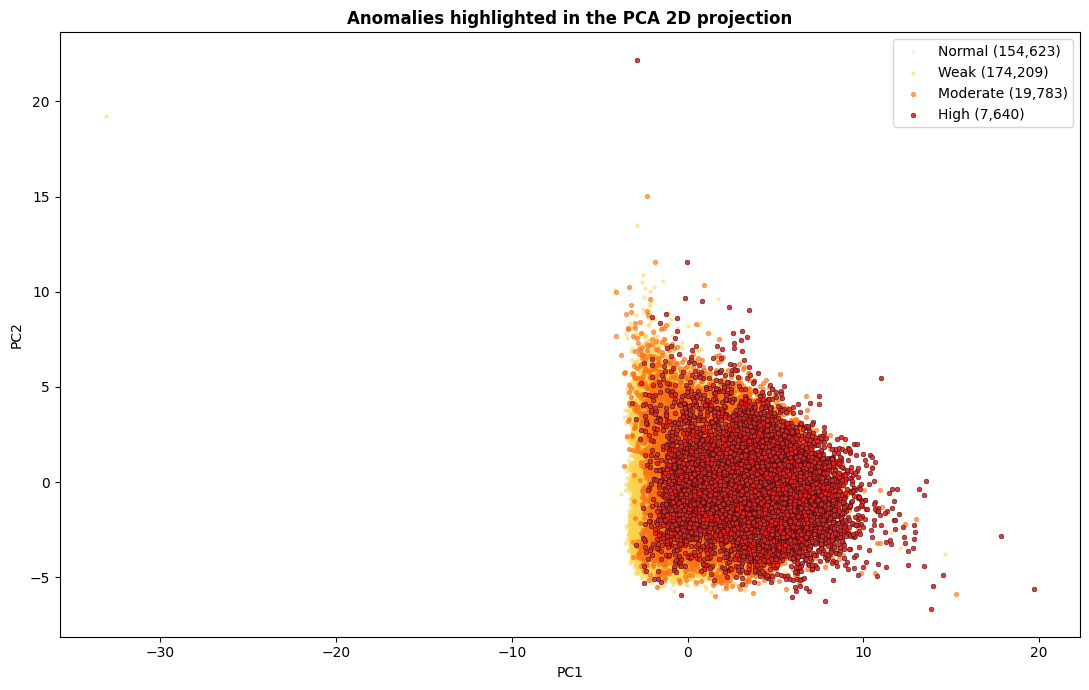

Saved pca_anomaly_sample.csv (36,954 rows for the dashboard)


In [7]:
# PCA scatter with anomalies highlighted
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca2 = pca.fit_transform(X_scaled)
merged_a_indexed = merged_a.reset_index(drop=True)
merged_a_indexed['PC1'] = X_pca2[:, 0]
merged_a_indexed['PC2'] = X_pca2[:, 1]

fig, ax = plt.subplots(figsize=(11, 7))
normal = merged_a_indexed[merged_a_indexed['anomaly_category']=='NORMAL']
weak = merged_a_indexed[merged_a_indexed['anomaly_category']=='WEAK_SIGNAL']
moderate = merged_a_indexed[merged_a_indexed['anomaly_category']=='MODERATE_ANOMALY']
high = merged_a_indexed[merged_a_indexed['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY']
ax.scatter(normal['PC1'], normal['PC2'], c='#CCCCCC', s=3, alpha=0.2, label=f'Normal ({len(normal):,})')
ax.scatter(weak['PC1'], weak['PC2'], c='#FCD34D', s=5, alpha=0.4, label=f'Weak ({len(weak):,})')
ax.scatter(moderate['PC1'], moderate['PC2'], c='#F97316', s=8, alpha=0.6, label=f'Moderate ({len(moderate):,})')
ax.scatter(high['PC1'], high['PC2'], c='#DC2626', s=12, alpha=0.9, label=f'High ({len(high):,})', edgecolors='black', linewidths=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Anomalies highlighted in the PCA 2D projection', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_pca_anomaly.png', dpi=150)
plt.show()

# Export a sample for the Phase 5 dashboard (all HIGH plus a sample of the rest)
high_idx = np.where(merged_a_indexed['anomaly_category'] == 'HIGH_CONFIDENCE_ANOMALY')[0]
rng_exp = np.random.default_rng(RANDOM_SEED)
base_idx = rng_exp.choice(len(merged_a_indexed), size=min(30000, len(merged_a_indexed)), replace=False)
keep_idx = np.unique(np.concatenate([base_idx, high_idx]))
merged_a_indexed.iloc[keep_idx][['PC1', 'PC2', 'anomaly_category', 'CLUSTER_KMEANS']].to_csv(
    OUT_DIR / 'pca_anomaly_sample.csv', index=False)
print(f'Saved pca_anomaly_sample.csv ({len(keep_idx):,} rows for the dashboard)')

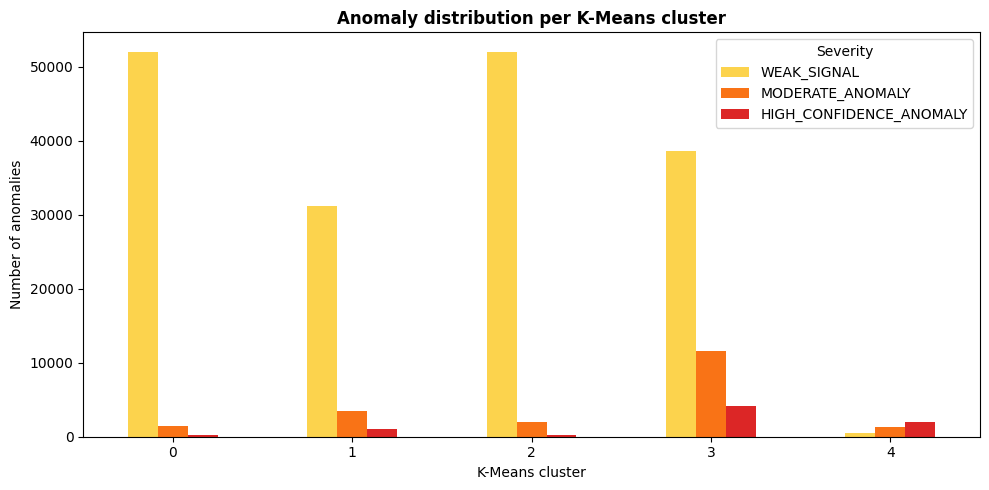

In [8]:
# Anomalies per cluster (heatmap-like bar)
cluster_anomalies = merged_a.groupby('CLUSTER_KMEANS')['anomaly_category'].value_counts().unstack(fill_value=0)
if 'NORMAL' in cluster_anomalies.columns:
    cluster_anomalies = cluster_anomalies.drop(columns=['NORMAL'])
cluster_anomalies_sorted = cluster_anomalies.reindex(columns=['WEAK_SIGNAL','MODERATE_ANOMALY','HIGH_CONFIDENCE_ANOMALY'])
fig, ax = plt.subplots(figsize=(10, 5))
cluster_anomalies_sorted.plot(kind='bar', stacked=False, ax=ax,
                              color=['#FCD34D','#F97316','#DC2626'])
ax.set_xlabel('K-Means cluster'); ax.set_ylabel('Number of anomalies')
ax.set_title('Anomaly distribution per K-Means cluster', fontweight='bold')
ax.legend(title='Severity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_anomaly_per_cluster.png', dpi=150)
plt.show()

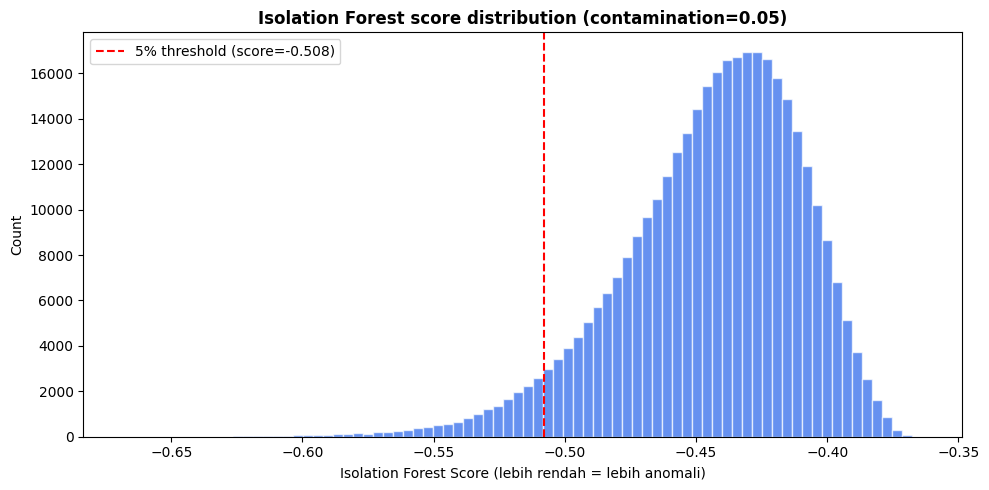

In [9]:
# Isolation Forest score distribution + threshold lines
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(iso_df['isolation_score'], bins=80, color='#2563EB', alpha=0.7, edgecolor='white')
thr05 = iso_df['isolation_score'].quantile(DEFAULT_CONTAM)
ax.axvline(thr05, color='red', ls='--', label=f'5% threshold (score={thr05:.3f})')
ax.set_xlabel('Isolation Forest Score (lebih rendah = lebih anomali)')
ax.set_ylabel('Count')
ax.set_title(f'Isolation Forest score distribution (contamination={DEFAULT_CONTAM})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_isolation_score_dist.png', dpi=150)
plt.show()

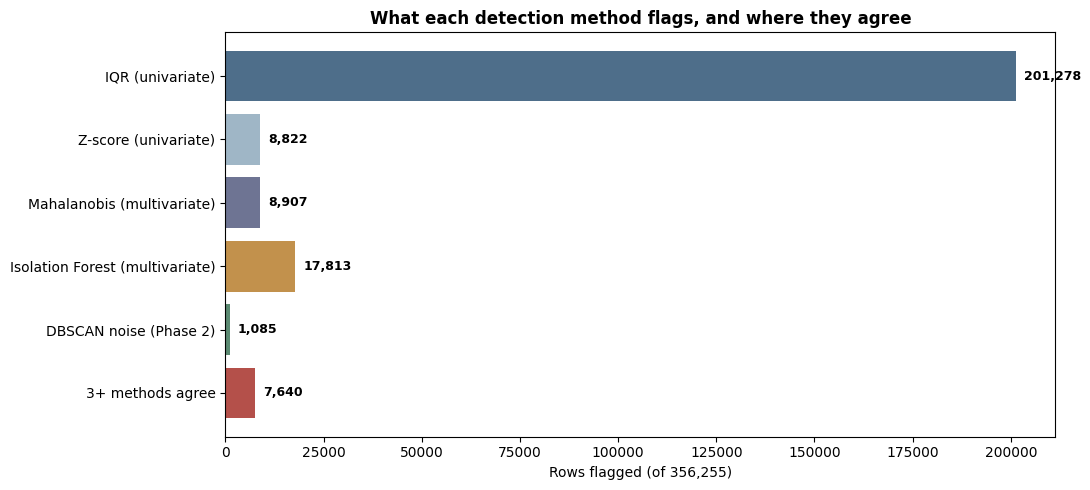

In [10]:
# Per-method comparison: how many rows each detector flags, and how many rows
# at least three of the five agree on. A five-set Venn is unreadable, so this
# stays a simple ranked bar.
method_counts = [
    ('IQR (univariate)', int(merged_a['is_iqr_outlier'].sum()), '#4E6E8A'),
    ('Z-score (univariate)', int(merged_a['is_zscore_outlier'].sum()), '#9FB6C6'),
    ('Mahalanobis (multivariate)', int(merged_a['is_mahalanobis_outlier'].sum()), '#6E7493'),
    ('Isolation Forest (multivariate)', int(merged_a['is_isolation_outlier'].sum()), '#C2914C'),
    ('DBSCAN noise (Phase 2)', int(merged_a['IS_OUTLIER'].fillna(0).sum()), '#5B8A72'),
    ('3+ methods agree', int((merged_a['detection_count'] >= 3).sum()), '#B4504A'),
]
fig, ax = plt.subplots(figsize=(11, 5))
names_m = [m[0] for m in method_counts]
vals_m = [m[1] for m in method_counts]
cols_m = [m[2] for m in method_counts]
bars = ax.barh(names_m[::-1], vals_m[::-1], color=cols_m[::-1])
for bar, v in zip(bars, vals_m[::-1]):
    ax.text(v + max(vals_m)*0.01, bar.get_y() + bar.get_height()/2, f'{v:,}',
            va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Rows flagged (of 356,255)')
ax.set_title('What each detection method flags, and where they agree', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_method_overlap.png', dpi=150)
plt.show()

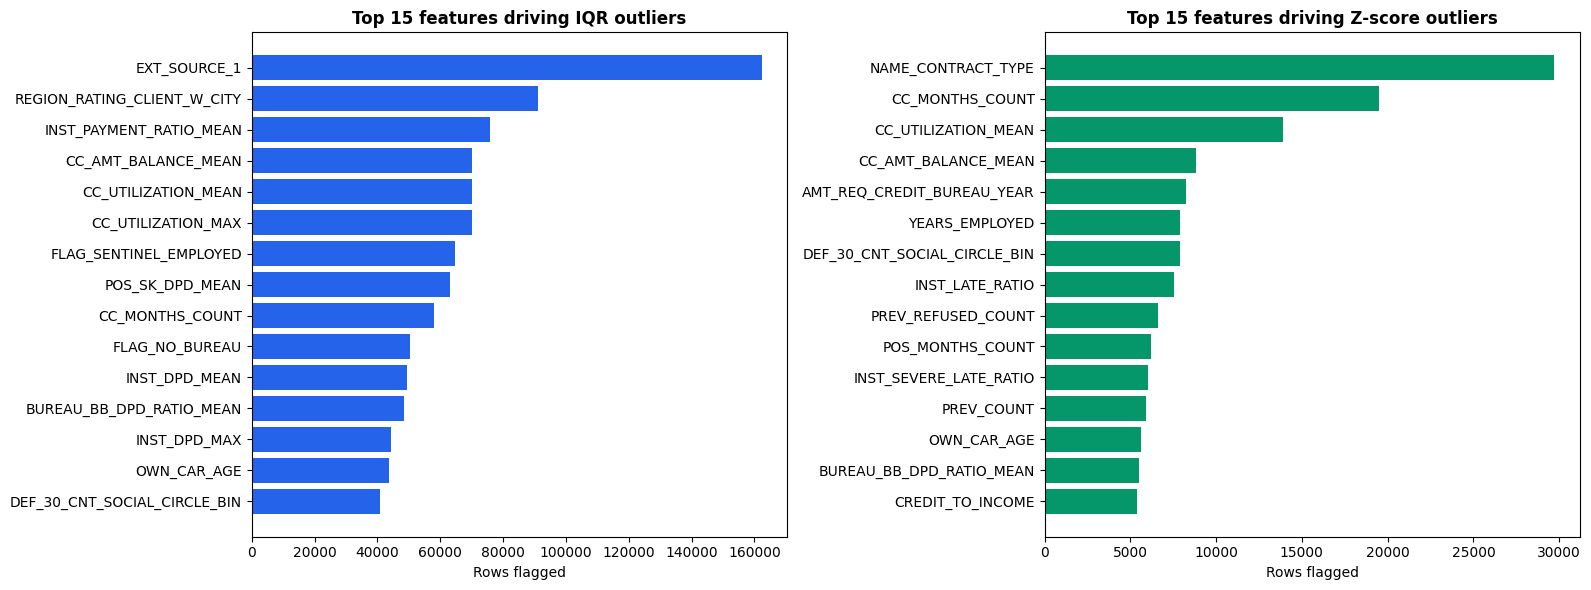

In [11]:
# Heatmap: features that drive anomalies the most
top_iqr_feats = iqr_flags.sum().sort_values(ascending=False).head(15)
top_z_feats = z_flags.sum().sort_values(ascending=False).head(15)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top_iqr_feats.index[::-1], top_iqr_feats.values[::-1], color='#2563EB')
axes[0].set_title('Top 15 features driving IQR outliers', fontweight='bold')
axes[0].set_xlabel('Rows flagged')
axes[1].barh(top_z_feats.index[::-1], top_z_feats.values[::-1], color='#059669')
axes[1].set_title('Top 15 features driving Z-score outliers', fontweight='bold')
axes[1].set_xlabel('Rows flagged')
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_anomaly_heatmap.png', dpi=150)
plt.show()

---
Phase 4 done. The artefacts are in `results/phase4_anomaly/`.